In [8]:
import numpy as np
import matplotlib.pyplot as plt


In [9]:
import os
import requests
import zipfile
from tqdm import tqdm # Optional: adds a nice progress bar

# Configuration
classes_to_download = ["walking", "boxing", "handclapping"]
base_url = "http://www.csc.kth.se/cvap/actions/"
output_dir = "./kth_videos/"

os.makedirs(output_dir, exist_ok=True)

def already_downloaded(action):
    for file in os.listdir(output_dir):
        if action in file:
            return True
    return False

def download_and_extract(action):
    if already_downloaded(action):
        print(f"✅ {action} videos already present. Skipping download.")
        return
    zip_filename = f"{action}.zip"
    url = f"{base_url}{zip_filename}"
    zip_path = os.path.join(output_dir, zip_filename)

    print(f"--- Processing '{action}' ---")
    
    # Downloading using requests (works on Windows/Mac/Linux)
    print(f"Downloading {url}...")
    response = requests.get(url, stream=True)
    if response.status_code == 200:
        with open(zip_path, 'wb') as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
    else:
        print(f"Failed to download {action}. Status code: {response.status_code}")
        return

    # Extracting using zipfile (built-in Python library)
    print(f"Extracting {zip_filename}...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(output_dir)

    # Clean up the zip file
    os.remove(zip_path)
    print(f"Done with {action}!\n")

if __name__ == "__main__":
    print("Starting downloads...")
    for action in classes_to_download:
        download_and_extract(action)
    print(f"All selected classes are ready in: {os.path.abspath(output_dir)}")

Starting downloads...
✅ walking videos already present. Skipping download.
✅ boxing videos already present. Skipping download.
✅ handclapping videos already present. Skipping download.
All selected classes are ready in: c:\Users\Hp\OneDrive\VL-JEPA-base-CCTV\kth_videos


In [10]:
import cv2
import numpy as np
import pandas as pd
import os

def process_kth_dataset(video_dir=r"C:\Users\Hp\OneDrive\VL-JEPA-base-CCTV\kth_videos", output_csv="kth_cctv_features.csv"):
    print(f"Scanning directory {video_dir} for KTH videos...")

    if not os.path.exists(video_dir):
        print(f"Error: Directory {video_dir} not found. Please ensure your videos are extracted here.")
        return 0

    video_files = [f for f in os.listdir(video_dir) if f.endswith('.avi')]
    print(f"Found {len(video_files)} video files. Starting feature extraction...")

    dataset_records = []
    label_to_id = {}
    current_class_id = 0

    for filename in video_files:

        action_label = filename.split('_')[1]

        if action_label not in label_to_id:
            label_to_id[action_label] = current_class_id
            current_class_id += 1

        target_class_id = label_to_id[action_label]
        video_path = os.path.join(video_dir, filename)
        cap = cv2.VideoCapture(video_path)

        # Sample 5 frames per video
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if total_frames < 20:
            cap.release()
            continue

        frames_to_sample = np.linspace(10, total_frames - 10, 5, dtype=int)

        for frame_idx in frames_to_sample:
            cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
            ret, frame = cap.read()
            if not ret: continue

            # Apply Simulated CCTV Occlusion Mask
            mask_x1, mask_x2 = 60, 100
            mask_y1, mask_y2 = 40, 80
            cv2.rectangle(frame, (mask_x1, mask_y1), (mask_x2, mask_y2), (0, 0, 0), -1)

            # Convert to HSV and extract 256-bin histogram
            hsv_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
            hist = cv2.calcHist([hsv_frame], [0, 1], None, [16, 16], [0, 180, 0, 256])
            cv2.normalize(hist, hist, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX)

            features = hist.flatten().tolist()

            dataset_records.append({
                "video_file": filename,
                "target_class": target_class_id,
                "hsv_features": features
            })

        cap.release()

    # Save to CSV
    df = pd.DataFrame(dataset_records)
    df.to_csv(output_csv, index=False)

    print("\n--- Extraction Complete! ---")
    print(f"Total frames processed: {len(df)}")
    print(f"Classes found: {label_to_id}")
    print(f"Saved dataset to {output_csv}")

    return len(label_to_id)

num_found_classes = process_kth_dataset()

Scanning directory C:\Users\Hp\OneDrive\VL-JEPA-base-CCTV\kth_videos for KTH videos...
Found 299 video files. Starting feature extraction...

--- Extraction Complete! ---
Total frames processed: 1494
Classes found: {'boxing': 0, 'handclapping': 1, 'walking': 2}
Saved dataset to kth_cctv_features.csv


In [11]:
# import numpy as np
# import pandas as pd
# import ast
# import matplotlib.pyplot as plt

# class FinalNumPyJEPA:
#     def __init__(self, input_dim, target_classes, embed_dim=64, lr=0.01):
#         self.lr = lr

#         self.W_v = np.random.randn(embed_dim, input_dim) * np.sqrt(2. / input_dim)
#         self.b_v = np.zeros((embed_dim, 1))

#         self.W_y = np.random.randn(embed_dim, target_classes) * np.sqrt(2. / target_classes)
#         self.b_y = np.zeros((embed_dim, 1))

#         self.W_p = np.random.randn(embed_dim, embed_dim) * np.sqrt(2. / embed_dim)
#         self.b_p = np.zeros((embed_dim, 1))

#     def relu(self, Z): return np.maximum(0, Z)
#     def relu_deriv(self, Z): return Z > 0

#     def forward(self, X_v, Y):
#         # Encoders
#         Z_v = np.dot(self.W_v, X_v) + self.b_v
#         self.S_v = self.relu(Z_v)
#         self.S_y = np.dot(self.W_y, Y) + self.b_y

#         # Predictor
#         self.S_y_hat = np.dot(self.W_p, self.S_v) + self.b_p

#         # JEPA Embedding Loss
#         loss = 0.5 * np.sum((self.S_y_hat - self.S_y)**2)
#         return loss, Z_v

#     def backward(self, X_v, Y, Z_v):
#         d_S_y_hat = self.S_y_hat - self.S_y

#         # Predictor Gradients
#         d_W_p = np.dot(d_S_y_hat, self.S_v.T)
#         d_b_p = d_S_y_hat

#         # Visual Encoder Gradients
#         d_S_v = np.dot(self.W_p.T, d_S_y_hat)
#         d_Z_v = d_S_v * self.relu_deriv(Z_v)
#         d_W_v = np.dot(d_Z_v, X_v.T)
#         d_b_v = d_Z_v

#         # Target Encoder Gradients
#         d_S_y = -d_S_y_hat
#         d_W_y = np.dot(d_S_y, Y.T)
#         d_b_y = d_S_y

#         # Weight Updates
#         self.W_p -= self.lr * d_W_p; self.b_p -= self.lr * d_b_p
#         self.W_v -= self.lr * d_W_v; self.b_v -= self.lr * d_b_v
#         self.W_y -= self.lr * d_W_y; self.b_y -= self.lr * d_b_y

# def run_training_and_plot(csv_path=r"C:\Users\Ayushman\VL-JEPA-base-CCTV\kth_motion_features2.csv", num_classes=3, epochs=40):
#     print(f"Loading dataset from {csv_path}...")
#     try:
#         df = pd.read_csv(csv_path)
#     except FileNotFoundError:
#         print("Error: CSV not found. Did you run the extraction cell first?")
#         return

#     df['hsv_features'] = df['hsv_features'].apply(ast.literal_eval)


#     model = FinalNumPyJEPA(input_dim=256, target_classes=num_classes, embed_dim=64, lr=0.005)
#     loss_history = []

#     print("Starting Training Simulation...")
#     for epoch in range(epochs):
#         df_shuffled = df.sample(frac=1).reset_index(drop=True)
#         epoch_loss = 0

#         for index, row in df_shuffled.iterrows():
#             X_v = np.array(row['hsv_features']).reshape(256, 1)
#             Y = np.zeros((num_classes, 1))
#             Y[int(row['target_class']), 0] = 1.0

#             loss, Z_v = model.forward(X_v, Y)
#             model.backward(X_v, Y, Z_v)
#             epoch_loss += loss

#         avg_loss = epoch_loss / len(df)
#         loss_history.append(avg_loss)
#         if (epoch+1) % 5 == 0 or epoch == 0:
#             print(f"Epoch {epoch+1}/{epochs} | Average JEPA Latent Loss: {avg_loss:.4f}")
   


#     plt.figure(figsize=(9, 5))
#     plt.plot(loss_history, marker='o', linestyle='-', color='#1f77b4', linewidth=2)
#     plt.title('VL-JEPA: NumPy Embedding-Space Training Loss', fontsize=14, fontweight='bold')
#     plt.xlabel('Training Epochs', fontsize=12)
#     plt.ylabel('L2 Latent Distance', fontsize=12)
#     plt.grid(True, linestyle='--', alpha=0.7)
#     plt.tight_layout()
#     plt.show()


# try:
#     run_training_and_plot(num_classes=num_found_classes, epochs=40)
# except NameError:

#     print("Please manually enter the number of classes found:")
#     manual_classes = int(input("> "))
#     run_training_and_plot(num_classes=manual_classes, epochs=40)


Loading Motion Features from C:\Users\Hp\OneDrive\VL-JEPA-base-CCTV\kth_spatial_motion3.csv...
Starting VL-JEPA Training on 299 samples...
Epoch 1/50 | JEPA Loss: 20.814810
Epoch 10/50 | JEPA Loss: 3.161935
Epoch 20/50 | JEPA Loss: 0.515665
Epoch 30/50 | JEPA Loss: 0.135453
Epoch 40/50 | JEPA Loss: 0.069488
Epoch 50/50 | JEPA Loss: 0.051006

Training Finished


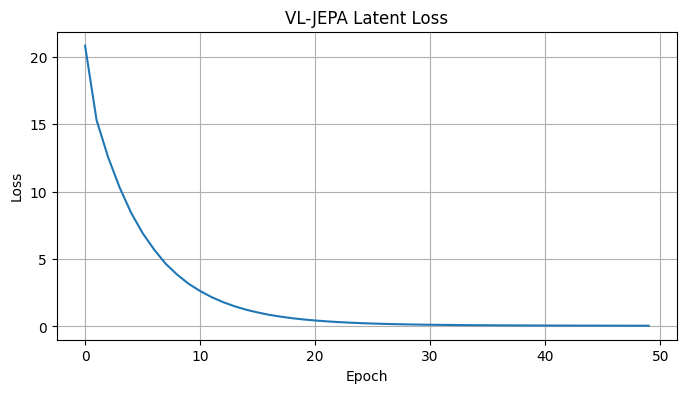

In [29]:
import numpy as np
import pandas as pd
import ast
import matplotlib.pyplot as plt

# ---------------- PATCH EMBEDDING ---------------- #

class PatchEmbedding:
    def __init__(self, img_size=224, patch_size=16, in_ch=3, embed_dim=256):

        self.patch_size = patch_size
        self.embed_dim = embed_dim
        self.num_patches = (img_size // patch_size) ** 2

        patch_dim = patch_size * patch_size * in_ch

        self.W = np.random.randn(patch_dim, embed_dim) / np.sqrt(patch_dim)

    def forward(self, x):
        # x shape → (B, H, W, C)

        B, H, W, C = x.shape
        p = self.patch_size

        patches = []

        for i in range(0, H, p):
            for j in range(0, W, p):
                patch = x[:, i:i+p, j:j+p, :].reshape(B, -1)
                patches.append(patch)

        patches = np.stack(patches, axis=1)   # (B, N, patch_dim)

        tokens = patches @ self.W             # (B, N, embed_dim)

        return tokens


# ---------------- LAYER NORM ---------------- #

class LayerNorm:
    def __init__(self, dim, eps=1e-5):
        self.gamma = np.ones((1, 1, dim))
        self.beta = np.zeros((1, 1, dim))
        self.eps = eps

    def forward(self, x):
        mean = x.mean(axis=-1, keepdims=True)
        var = x.var(axis=-1, keepdims=True)
        x_norm = (x - mean) / np.sqrt(var + self.eps)
        return self.gamma * x_norm + self.beta


# ---------------- MLP ---------------- #

class MLP:
    def __init__(self, dim, hidden_dim):
        self.W1 = np.random.randn(dim, hidden_dim) / np.sqrt(dim)
        self.W2 = np.random.randn(hidden_dim, dim) / np.sqrt(hidden_dim)

    def gelu(self, x):
        return 0.5 * x * (1 + np.tanh(
            np.sqrt(2/np.pi) * (x + 0.044715 * np.power(x, 3))
        ))

    def forward(self, x):
        return self.gelu(x @ self.W1) @ self.W2


# ---------------- MULTI HEAD ATTENTION ---------------- #

class MultiHeadSelfAttention:
    def __init__(self, dim, heads=8):

        self.dim = dim
        self.heads = heads
        self.head_dim = dim // heads

        self.Wq = np.random.randn(dim, dim) / np.sqrt(dim)
        self.Wk = np.random.randn(dim, dim) / np.sqrt(dim)
        self.Wv = np.random.randn(dim, dim) / np.sqrt(dim)
        self.Wo = np.random.randn(dim, dim) / np.sqrt(dim)

    def forward(self, x):

        B, N, D = x.shape

        Q = x @ self.Wq
        K = x @ self.Wk
        V = x @ self.Wv

        Q = Q.reshape(B, N, self.heads, self.head_dim).transpose(0,2,1,3)
        K = K.reshape(B, N, self.heads, self.head_dim).transpose(0,2,1,3)
        V = V.reshape(B, N, self.heads, self.head_dim).transpose(0,2,1,3)

        scores = Q @ K.transpose(0,1,3,2) / np.sqrt(self.head_dim)

        attn = np.exp(scores)
        attn = attn / attn.sum(axis=-1, keepdims=True)

        out = attn @ V

        out = out.transpose(0,2,1,3).reshape(B, N, D)

        return out @ self.Wo


# ---------------- TRANSFORMER BLOCK ---------------- #

class TransformerBlock:
    def __init__(self, dim, heads):

        self.norm1 = LayerNorm(dim)
        self.norm2 = LayerNorm(dim)

        self.attn = MultiHeadSelfAttention(dim, heads)
        self.mlp = MLP(dim, dim*4)

    def forward(self, x):

        x = x + self.attn.forward(self.norm1.forward(x))
        x = x + self.mlp.forward(self.norm2.forward(x))

        return x


# ---------------- VISION TRANSFORMER ---------------- #

class NumPyViT:
    def __init__(self,
                 img_size=224,
                 patch_size=16,
                 embed_dim=256,
                 depth=6,
                 heads=8):

        self.patch_embed = PatchEmbedding(
            img_size,
            patch_size,
            3,
            embed_dim
        )

        num_patches = self.patch_embed.num_patches

        self.pos_embed = np.random.randn(1, num_patches, embed_dim)

        self.blocks = [
            TransformerBlock(embed_dim, heads)
            for _ in range(depth)
        ]

        self.norm = LayerNorm(embed_dim)

    def forward(self, x):

        x = self.patch_embed.forward(x)

        x = x + self.pos_embed

        for blk in self.blocks:
            x = blk.forward(x)

        x = self.norm.forward(x)

        return x        # LATENT TOKENS FOR VL-JEPA
    
# --- 1. The JEPA Class (Remains the same as your stable version) ---
class FinalNumPyJEPA:
    def __init__(self, img_size=224, patch_size=16,embed_dim=64, target_classes=10, lr=0.01):

        self.lr = lr
        self.vit = NumPyViT(
            img_size=img_size,
            patch_size=patch_size,
            embed_dim=embed_dim,
            depth=4,
            heads=4
        )
        self.W_y = np.random.randn(embed_dim, target_classes) * np.sqrt(2. / target_classes)
        self.b_y = np.zeros((embed_dim, 1))
        self.W_p = np.random.randn(embed_dim, embed_dim) * np.sqrt(2. / embed_dim)
        self.b_p = np.zeros((embed_dim, 1))

    def forward(self, image, Y):

        #  ViT latent tokens
        tokens = self.vit.forward(image)
        # shape → (B , N , D)

        #  Global Average Pooling (JEPA uses token pooling)
        S_v = tokens.mean(axis=1).T
        # shape → (D , B)

        self.S_v = S_v

        #  Target Latent
        self.S_y = np.dot(self.W_y, Y) + self.b_y

        #  Predictor Latent
        self.S_y_hat = np.dot(self.W_p, self.S_v) + self.b_p

        #  JEPA Latent Loss
        loss = 0.5 * np.sum((self.S_y_hat - self.S_y) ** 2)

        return loss

    def backward(self, image, Y):

    # --------- JEPA Loss Gradient ----------
        d_S_y_hat = self.S_y_hat - self.S_y

    # --------- Predictor Grad ----------
        d_W_p = np.dot(d_S_y_hat, self.S_v.T)
        d_b_p = np.sum(d_S_y_hat, axis=1, keepdims=True)

        d_S_v = np.dot(self.W_p.T, d_S_y_hat)

    #  STOP GRADIENT HERE (No ViT backward)
    # We DO NOT propagate inside ViT

    # --------- Target Encoder Grad ----------
        d_S_y = -d_S_y_hat

        d_W_y = np.dot(d_S_y, Y.T)
        d_b_y = np.sum(d_S_y, axis=1, keepdims=True)

    # --------- Update ----------
        self.W_p -= self.lr * d_W_p
        self.b_p -= self.lr * d_b_p

        self.W_y -= self.lr * d_W_y
        self.b_y -= self.lr * d_b_y

# --- 2. Inference Helper ---
def predict(model, feat, num_classes):

    # 🔥 Convert to flat vector (VERY IMPORTANT)
    feat = np.array(feat).flatten()

    # Normalization
    feat = (feat - feat.min()) / (feat.max() - feat.min() + 1e-8)

    # Required fake image size
    required = 224 * 224 * 3

    repeat = int(np.ceil(required / len(feat)))

    img = np.tile(feat, repeat)[:required]

    img = img.reshape(1, 224, 224, 3)

    # ViT forward
    tokens = model.vit.forward(img)

    S_v = tokens.mean(axis=1).T

    # Predictor
    S_y_hat = model.W_p @ S_v + model.b_p

    distances = []

    for i in range(num_classes):
        Y = np.zeros((num_classes, 1))
        Y[i, 0] = 1

        S_y = model.W_y @ Y + model.b_y

        distances.append(np.linalg.norm(S_y_hat - S_y))

    return np.argmin(distances)

# --- 3. Training Logic ---
def run_training_and_plot(csv_path, num_classes=3, epochs=50):

    print(f"Loading Motion Features from {csv_path}...")

    try:
        df = pd.read_csv(csv_path)
        feature_col = 'features' if 'features' in df.columns else 'hsv_features'
        df[feature_col] = df[feature_col].apply(ast.literal_eval)
    except Exception as e:
        print(f"Error: {e}")
        return

    model = FinalNumPyJEPA(
        img_size=224,
        patch_size=16,
        embed_dim=64,
        target_classes=num_classes,
        lr=0.001
    )

    loss_history = []

    print(f"Starting VL-JEPA Training on {len(df)} samples...")

    for epoch in range(epochs):

        df_shuffled = df.sample(frac=1).reset_index(drop=True)
        epoch_loss = 0

        for _, row in df_shuffled.iterrows():

            # -------- Motion Feature → Fake Image --------
            feat = np.array(row[feature_col])

            # normalize
            feat = (feat - feat.min()) / (feat.max() - feat.min() + 1e-8)

            # make fake RGB image
            img = np.tile(feat, 224*224*3 // len(feat) + 1)[:224*224*3]
            img = img.reshape(1,224,224,3)

            # -------- Target One Hot --------
            Y = np.zeros((num_classes,1))
            Y[int(row['target_class']),0] = 1.0

            # -------- Forward --------
            loss = model.forward(img, Y)

            # -------- Backward --------
            model.backward(img, Y)

            epoch_loss += loss

        avg_loss = epoch_loss / len(df)
        loss_history.append(avg_loss)

        if (epoch+1)%10==0 or epoch==0:
            print(f"Epoch {epoch+1}/{epochs} | JEPA Loss: {avg_loss:.6f}")

    print("\nTraining Finished")

    # -------- Plot --------
    plt.figure(figsize=(8,4))
    plt.plot(loss_history)
    plt.title("VL-JEPA Latent Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()

    return model


# --- 4. Execution ---
csv_file = r"C:\Users\Hp\OneDrive\VL-JEPA-base-CCTV\kth_spatial_motion3.csv"
# You can set num_classes to 3 since we are doing walking, boxing, handclapping
trained_model = run_training_and_plot(csv_file, num_classes=3, epochs=50)

Index(['video_file', 'target_class', 'features'], dtype='str')


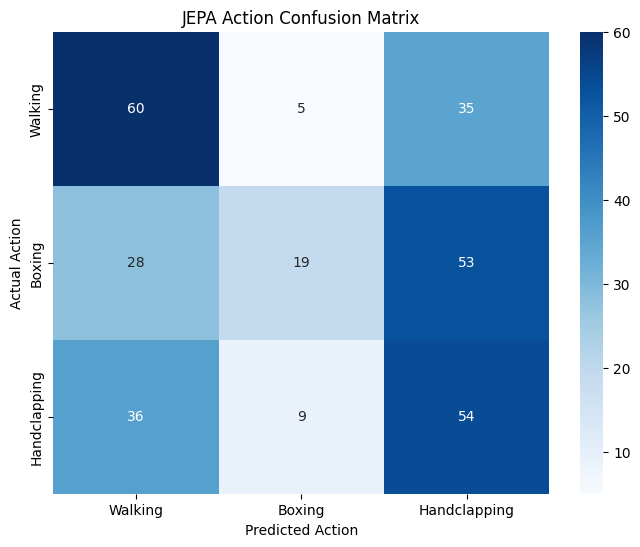


Detailed Performance Report:
              precision    recall  f1-score   support

     Walking       0.48      0.60      0.54       100
      Boxing       0.58      0.19      0.29       100
Handclapping       0.38      0.55      0.45        99

    accuracy                           0.44       299
   macro avg       0.48      0.45      0.42       299
weighted avg       0.48      0.44      0.42       299



In [30]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import ast
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrix(model, df, num_classes, label_names, feature_col='features'):
    y_true = []
    y_pred = []
    
    for _, row in df.iterrows():
        
        # 🔥 Convert string list → real list
        feature_vector = ast.literal_eval(row[feature_col])
        
        X_v = np.array(feature_vector).reshape(256, 1)
        
        true_label = int(row['target_class'])
        
        pred_label = predict(model, X_v, num_classes)
        
        y_true.append(true_label)
        y_pred.append(pred_label)
    
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names)
    plt.title('JEPA Action Confusion Matrix')
    plt.ylabel('Actual Action')
    plt.xlabel('Predicted Action')
    plt.show()

    print("\nDetailed Performance Report:")
    print(classification_report(y_true, y_pred, target_names=label_names))

    
# Usage (Assuming your labels are in this order):
labels = ["Walking", "Boxing", "Handclapping"]
df = pd.read_csv(r"C:\Users\Hp\OneDrive\VL-JEPA-base-CCTV\kth_spatial_motion3.csv")
print(df.columns)
plot_confusion_matrix(trained_model, df, 3, labels)

In [26]:
def test_model(model, feat, num_classes):

    # -------- Motion Vector → Fake Image --------
    feat = np.array(feat)

    feat = (feat - feat.min()) / (feat.max() - feat.min() + 1e-8)

    img = np.tile(feat, 224*224*3 // len(feat) + 1)[:224*224*3]
    img = img.reshape(1, 224, 224, 3)

    # -------- ViT Forward --------
    tokens = model.vit.forward(img)

    # Global Average Pooling
    S_v = tokens.mean(axis=1).T

    # Predictor latent
    S_y_hat = model.W_p @ S_v + model.b_p

    # -------- Distance to class embeddings --------
    distances = []

    for i in range(num_classes):
        Y = np.zeros((num_classes,1))
        Y[i,0] = 1

        S_y = model.W_y @ Y + model.b_y

        dist = np.linalg.norm(S_y_hat - S_y)
        distances.append(dist)

    return np.argmin(distances), distances

In [27]:
def evaluate_accuracy(model, csv_path, num_classes):

    df = pd.read_csv(csv_path)

    feature_col = 'features' if 'features' in df.columns else 'hsv_features'
    df[feature_col] = df[feature_col].apply(ast.literal_eval)

    correct = 0
    total = len(df)

    print(f"\n--- Evaluating on {total} samples ---")

    for _, row in df.iterrows():

        feat = np.array(row[feature_col])

        # -------- Motion Vector → Fake Image --------
        feat = (feat - feat.min())/(feat.max() - feat.min() + 1e-8)

        img = np.tile(feat, 224*224*3 // len(feat) + 1)[:224*224*3]
        img = img.reshape(1,224,224,3)

        # -------- Forward ViT --------
        tokens = model.vit.forward(img)

        S_v = tokens.mean(axis=1).T

        S_y_hat = model.W_p @ S_v + model.b_p

        distances = []

        for i in range(num_classes):
            Y = np.zeros((num_classes,1))
            Y[i,0] = 1
            S_y = model.W_y @ Y + model.b_y
            distances.append(np.linalg.norm(S_y_hat - S_y))

        predicted_class = np.argmin(distances)

        actual_class = int(row['target_class'])

        if predicted_class == actual_class:
            correct += 1

    accuracy = (correct / total) * 100
    print(f"Accuracy: {accuracy:.2f}% ({correct}/{total})")

In [28]:
import cv2
import numpy as np
import os
import pandas as pd

def get_motion_signature(video_path):

    cap = cv2.VideoCapture(video_path)

    flows_mag = []
    flows_ang = []

    ret, prev = cap.read()
    if not ret:
        cap.release()
        return None

    prev = cv2.resize(prev, (128,128))
    prev_gray = cv2.cvtColor(prev, cv2.COLOR_BGR2GRAY)

    frame_count = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame = cv2.resize(frame, (128,128))
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        flow = cv2.calcOpticalFlowFarneback(
            prev_gray, gray,
            None, 0.5, 3, 15, 3, 5, 1.2, 0
        )

        mag, ang = cv2.cartToPolar(flow[...,0], flow[...,1])

        flows_mag.append(mag.flatten())
        flows_ang.append(ang.flatten())

        prev_gray = gray
        frame_count += 1

        if frame_count > 20:   # use only first 20 transitions
            break

    cap.release()

    if len(flows_mag) == 0:
        return None

    mag_all = np.concatenate(flows_mag)
    ang_all = np.concatenate(flows_ang)

    hist_mag = np.histogram(mag_all, bins=128)[0]
    hist_ang = np.histogram(ang_all, bins=128, range=(0,2*np.pi))[0]

    motion_features = np.concatenate([hist_mag, hist_ang]).astype(np.float32)

    motion_features /= (np.linalg.norm(motion_features) + 1e-8)

    return motion_features.tolist()

df = pd.DataFrame(dataset_records)
df.to_csv("kth_motion_features2.csv", index=False)
print("Done! Use 'kth_motion_features.csv' for training now.")

Done! Use 'kth_motion_features.csv' for training now.
